## Assignment 5: Numpy and Matplotlib


In [2]:
# 1
import numpy as np
from matplotlib import pyplot as plt

In [45]:
# 1.1
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)

xx, yy = np.meshgrid(x, y)

Text(0.5, 1.0, 'xx')

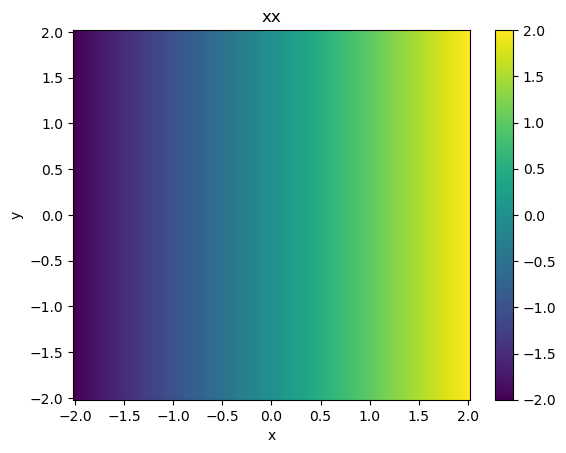

In [48]:
# 1.2
plt.figure()
plt.pcolormesh(x, y, xx)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('xx')

Text(0.5, 1.0, 'yy')

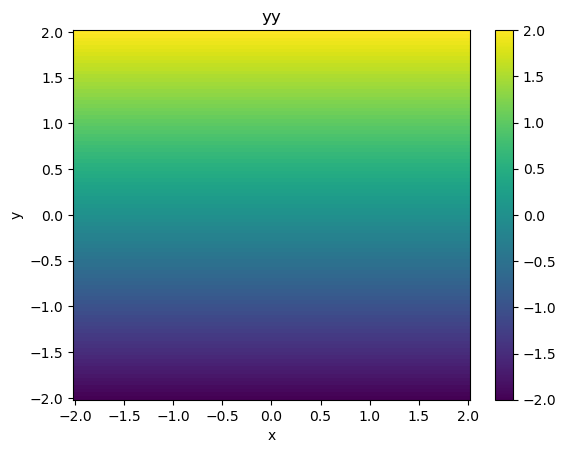

In [49]:
plt.figure()
plt.pcolormesh(x, y, yy)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('yy')

In [40]:
# 1.3 
r = np.sqrt(xx**2 + yy**2)
phi = np.arctan2(yy, xx)

Text(0.5, 1.0, 'r')

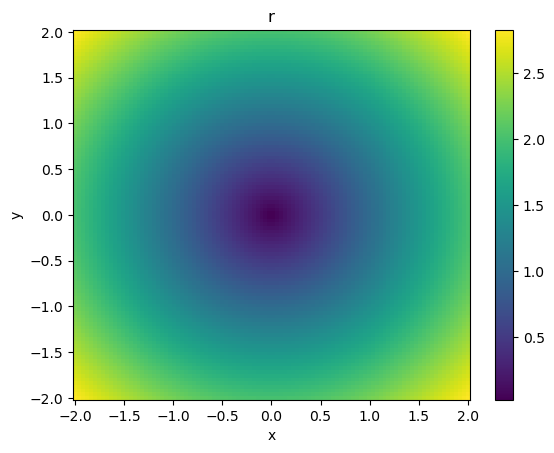

In [51]:
# 1.4
plt.figure()
plt.pcolormesh(x, y, r)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('r')

Text(0.5, 1.0, 'phi')

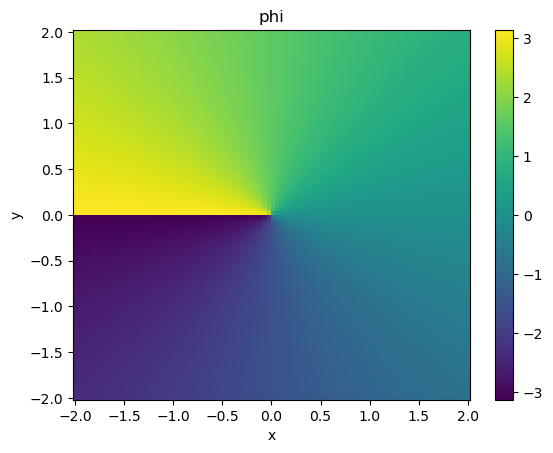

In [52]:
plt.figure()
plt.pcolormesh(x, y, phi)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('phi')

Text(0.5, 1.0, 'f = cos²(4r) + sin²(4φ)')

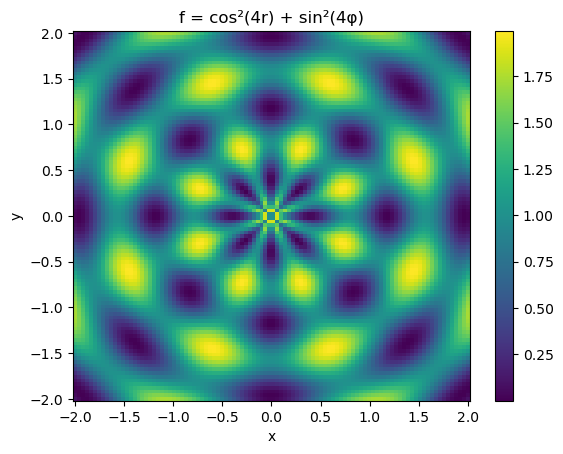

In [53]:
#1.5 
f = np.cos(4*r)**2 + np.sin(4*phi)**2

plt.figure()
plt.pcolormesh(x, y, f)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('f = cos²(4r) + sin²(4φ)')

#### Part 2: Analyze ARGO Data

In [54]:
# 2
import pooch
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
files

['/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

In [55]:
# 2.1
T = np.load("/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy")
S = np.load("/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy")
P = np.load("/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy")
date = np.load("/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy")
lat = np.load("/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy")
lon = np.load("/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy")
level = np.load("/home/cei2119/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy")

In [56]:
# 2.2
print(lat.shape)
print(lon.shape)
print(date.shape)
print(level.shape)

(75,)
(75,)
(75,)
(78,)


Im guessing that lat and lon are grid boxes like x and y and levels is about height or z, then date is another dimension of layer, so similar to stacking an array of 3d plots

Text(0.5, 1.0, 'Temperature Profiles')

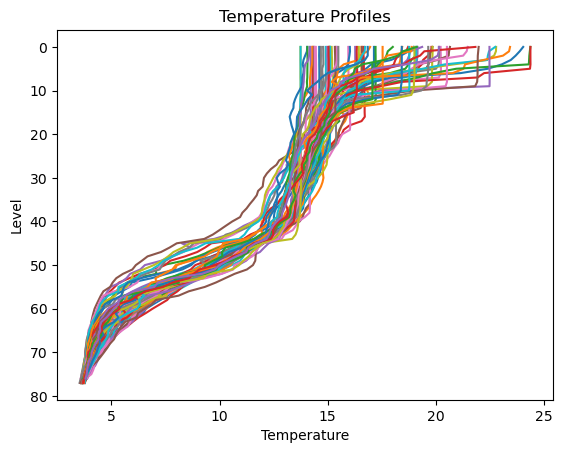

In [57]:
# 2.3
# Temperature
plt.figure()
plt.plot(T, level)
plt.gca().invert_yaxis()
plt.xlabel('Temperature')
plt.ylabel('Level')
plt.title('Temperature Profiles')

Text(0.5, 1.0, 'Salinity Profiles')

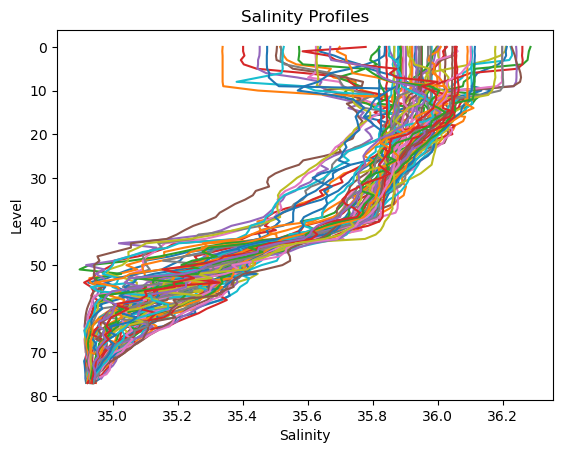

In [58]:
# Salinity
plt.figure()
plt.plot(S, level)
plt.gca().invert_yaxis()
plt.xlabel('Salinity')
plt.ylabel('Level')
plt.title('Salinity Profiles')

Text(0.5, 1.0, 'Pressure Profiles')

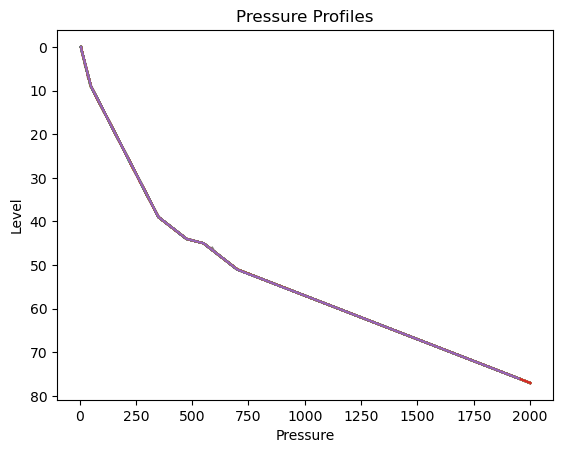

In [59]:
# Pressure
plt.figure()
plt.plot(P, level)
plt.gca().invert_yaxis()
plt.xlabel('Pressure')
plt.ylabel('Level')
plt.title('Pressure Profiles')

In [60]:
# 2.4
Tmean = np.mean(T, axis=1)
Tstd  = np.std(T, axis=1)

Smean = np.mean(S, axis=1)
Sstd  = np.std(S, axis=1)

Pmean = np.mean(P, axis=1)
Pstd  = np.std(P, axis=1)

Text(0.5, 1.0, 'Mean Temperature')

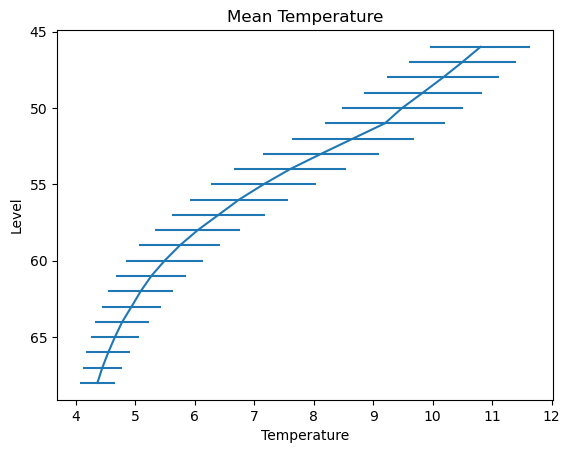

In [61]:
# 2.5
# Temperature
plt.figure()
plt.gca().invert_yaxis()
plt.errorbar(Tmean, level, xerr=Tstd)
plt.xlabel('Temperature')
plt.ylabel('Level')
plt.title('Mean Temperature')

Text(0.5, 1.0, 'Mean Salinity')

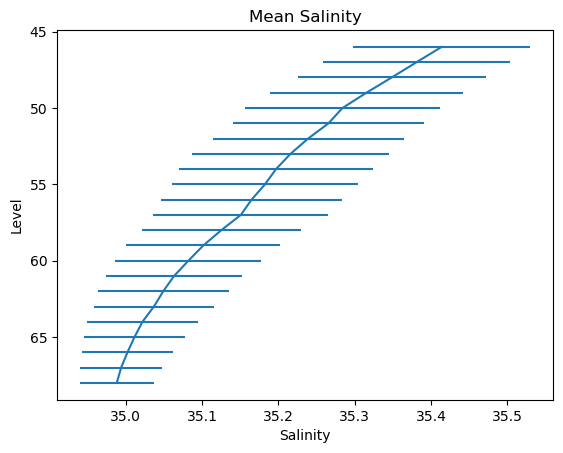

In [62]:
# Salinity
plt.figure()
plt.gca().invert_yaxis()
plt.errorbar(Smean, level, xerr=Sstd)
plt.xlabel('Salinity')
plt.ylabel('Level')
plt.title('Mean Salinity')

Text(0.5, 1.0, 'Mean Pressure')

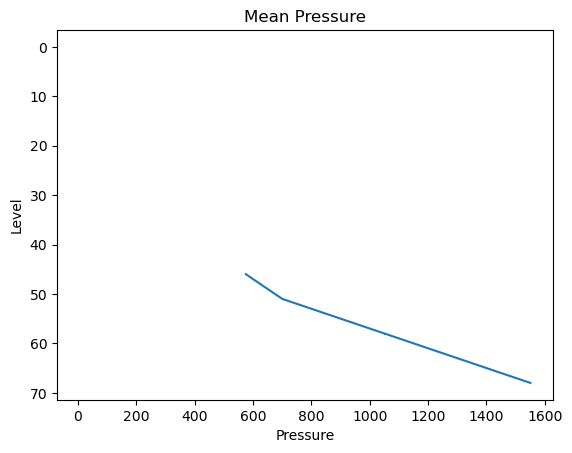

In [63]:
# Pressure
plt.figure()
plt.gca().invert_yaxis()
plt.errorbar(Pmean, level, xerr=Pstd)
plt.xlabel('Pressure')
plt.ylabel('Level')
plt.title('Mean Pressure')

In [64]:
# 2.6
#Same as 2.4 but with nan
Tnanmean = np.nanmean(T, axis=1)
Tnanstd  = np.nanstd(T, axis=1)

Snanmean = np.nanmean(S, axis=1)
Snanstd  = np.nanstd(S, axis=1)

Pnanmean = np.nanmean(P, axis=1)
Pnanstd  = np.nanstd(P, axis=1)

Text(0.5, 1.0, 'Mean Temperature')

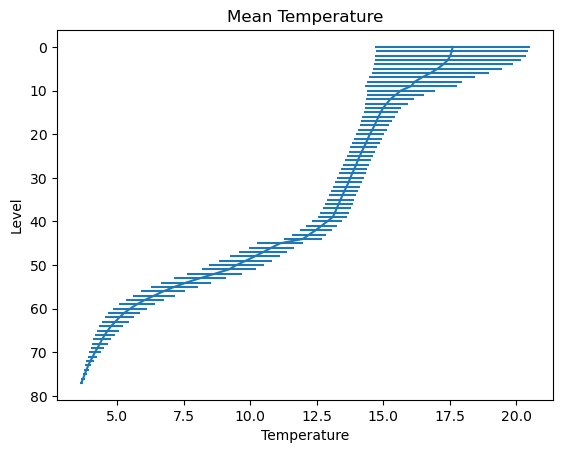

In [65]:
# Temperature
plt.figure()
plt.gca().invert_yaxis()
plt.errorbar(Tnanmean, level, xerr=Tnanstd)
plt.xlabel('Temperature')
plt.ylabel('Level')
plt.title('Mean Temperature')

Text(0.5, 1.0, 'Mean Salinity')

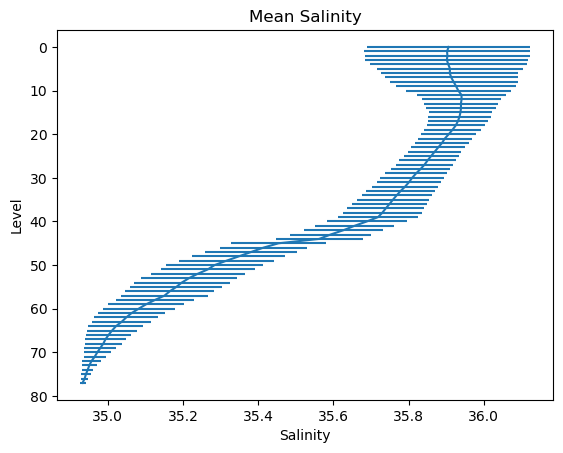

In [66]:
# Salinity
plt.figure()
plt.gca().invert_yaxis()
plt.errorbar(Snanmean, level, xerr=Snanstd)
plt.xlabel('Salinity')
plt.ylabel('Level')
plt.title('Mean Salinity')

Text(0.5, 1.0, 'Mean Pressure')

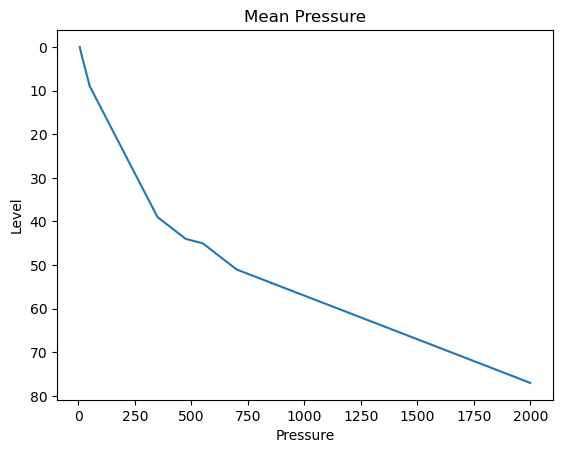

In [67]:
# Pressure
plt.figure()
plt.gca().invert_yaxis()
plt.errorbar(Pnanmean, level, xerr=Pnanstd)
plt.xlabel('Pressure')
plt.ylabel('Level')
plt.title('Mean Pressure')

Text(0.5, 1.0, 'ARGO Float Graph')

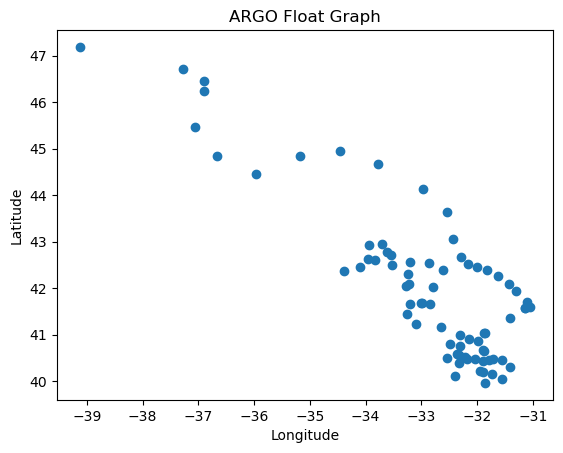

In [68]:
# 2.7
plt.figure()
plt.scatter(lon, lat)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('ARGO Float Graph')